In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
from matplotlib.ticker import MultipleLocator
from Thermography_tools import PCT
from helper_functions.helper_functions import resize_tensor
from scipy import ndimage as ndi
from matplotlib.ticker import MultipleLocator, PercentFormatter
from Metrics_experimental_data import *


In [2]:
from data.data_operators import BScanDepthDataset,ComposeBScanTransforms
from networks.Unets import BnetSmallKernel,BnetMean,BnetSmallKernelSmarter,BnetSmallKernelSmarterRefine,BnetSwinTransformer
from torch.utils.data import DataLoader
from helper_functions.helper_functions import *
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import os

In [22]:
data=np.load('/home/jaworskj/Desktop/Bscan_thermography_dataset/training/2026_03_26_cfrp_multiple_fbh_gauss_heat_5s_30s_45W_multiple_fbh_004.npz',allow_pickle=True)
data['meta']

array([['time', '27/03/2026 10:59:13'],
       ['lamp_power', 45],
       ['lamp_power_units', 'W'],
       ['T1', 4],
       ['T1_units', 'frames'],
       ['T2', 250],
       ['T2_units', 'frames'],
       ['T3', 1500],
       ['T3_units', 'frames'],
       ['fps', 50.0],
       ['fps_units', 'frames/s'],
       ['height', 512],
       ['height_units', 'pixels'],
       ['width', 512],
       ['width_units', 'pixels'],
       ['sequence_length', 1754],
       ['sequence_length_units', 'frames'],
       ['working_distance', 200.0],
       ['working_distance_units', 'mm'],
       ['thickness', 0.0035],
       ['thickness_units', 'm'],
       ['size_X', 0.1],
       ['size_X_units', 'm'],
       ['size_Y', 0.1],
       ['size_Y_units', 'm'],
       ['thermal_conductivity_x', 2.23],
       ['thermal_conductivity_x_units', 'W/(m·K)'],
       ['thermal_conductivity_y', 1.95],
       ['thermal_conductivity_y_units', 'W/(m·K)'],
       ['thermal_conductivity_z', 0.93],
       ['thermal_condu

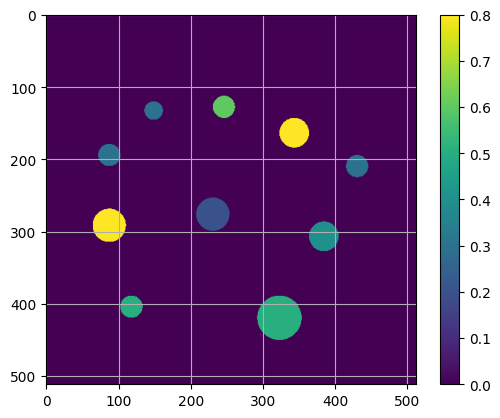

In [23]:
plt.imshow(data['mask'])
plt.colorbar()
plt.grid()

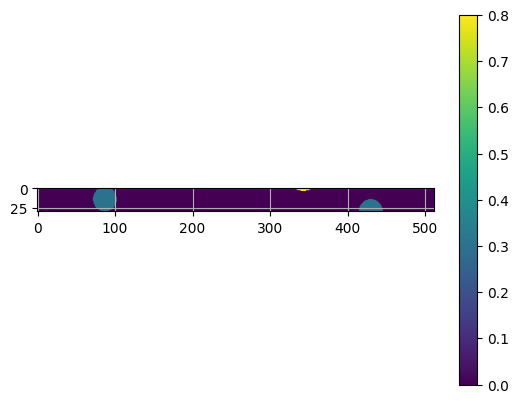

In [25]:
plt.imshow(data['mask'][180:210,])
plt.colorbar()
plt.grid()

In [3]:
device = 'cuda'
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [24]:
THICKNESS_MM = 5 

path_mean='/home/jaworskj/projects/thermal_B_scan/open_source_dataset/Model_performance_open_source_publication/Bnet_mean/best_model_clean.pth'

data_test='/home/jaworskj/projects/thermal_B_scan/open_source_dataset/testing/data_bscans'
mask_test='/home/jaworskj/projects/thermal_B_scan/open_source_dataset/testing/data_masks'

normalization_path="/home/jaworskj/projects/thermal_B_scan/normalization_params_experimental_cooling_only.npz"

model=BnetMean().to(device)
state_dict=torch.load(path_mean)
model.load_state_dict(state_dict)
model.eval()

projection_mode=None # ---------------------------- Projection modes--------------------------------------
cooling_phase=True
derivative_mode=None

test_dataset = BScanDepthDataset(
    bscan_dir=data_test,
    depth_dir=mask_test,
    transform=None,
    normalization_path=normalization_path,
    cooling_phase=cooling_phase,
    cooling_frame=0
)

# -------------------------
# Loaders
# -------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [25]:
model.eval()
pred_all = []
mask_all = []


with torch.no_grad():
    for X, mask in tqdm(test_loader):
        X = X.to(device)
        mask = mask.to(device)

        pred = model(X)

        pred_all.append(pred.cpu())
        mask_all.append(mask.cpu())

pred_all = torch.cat(pred_all, dim=0)
mask_all = torch.cat(mask_all, dim=0)

100%|██████████| 131/131 [00:04<00:00, 28.52it/s]


In [17]:
metrics, median_pred, inner_mask = calculate_median_depth_errors(
    pred_all[:,50:-50],
    mask_all[:,50:-50],
    erosion_pixels=1,
    inner_percent=100
)

print(f"Metrics-> Mae:{metrics['mae']*5:.3} mm | MedAE:{metrics['medae']*5:.3} mm | RMSE:{metrics['rmse']*5:.3} mm")

Metrics-> Mae:0.132 mm | MedAE:0.0823 mm | RMSE:0.305 mm


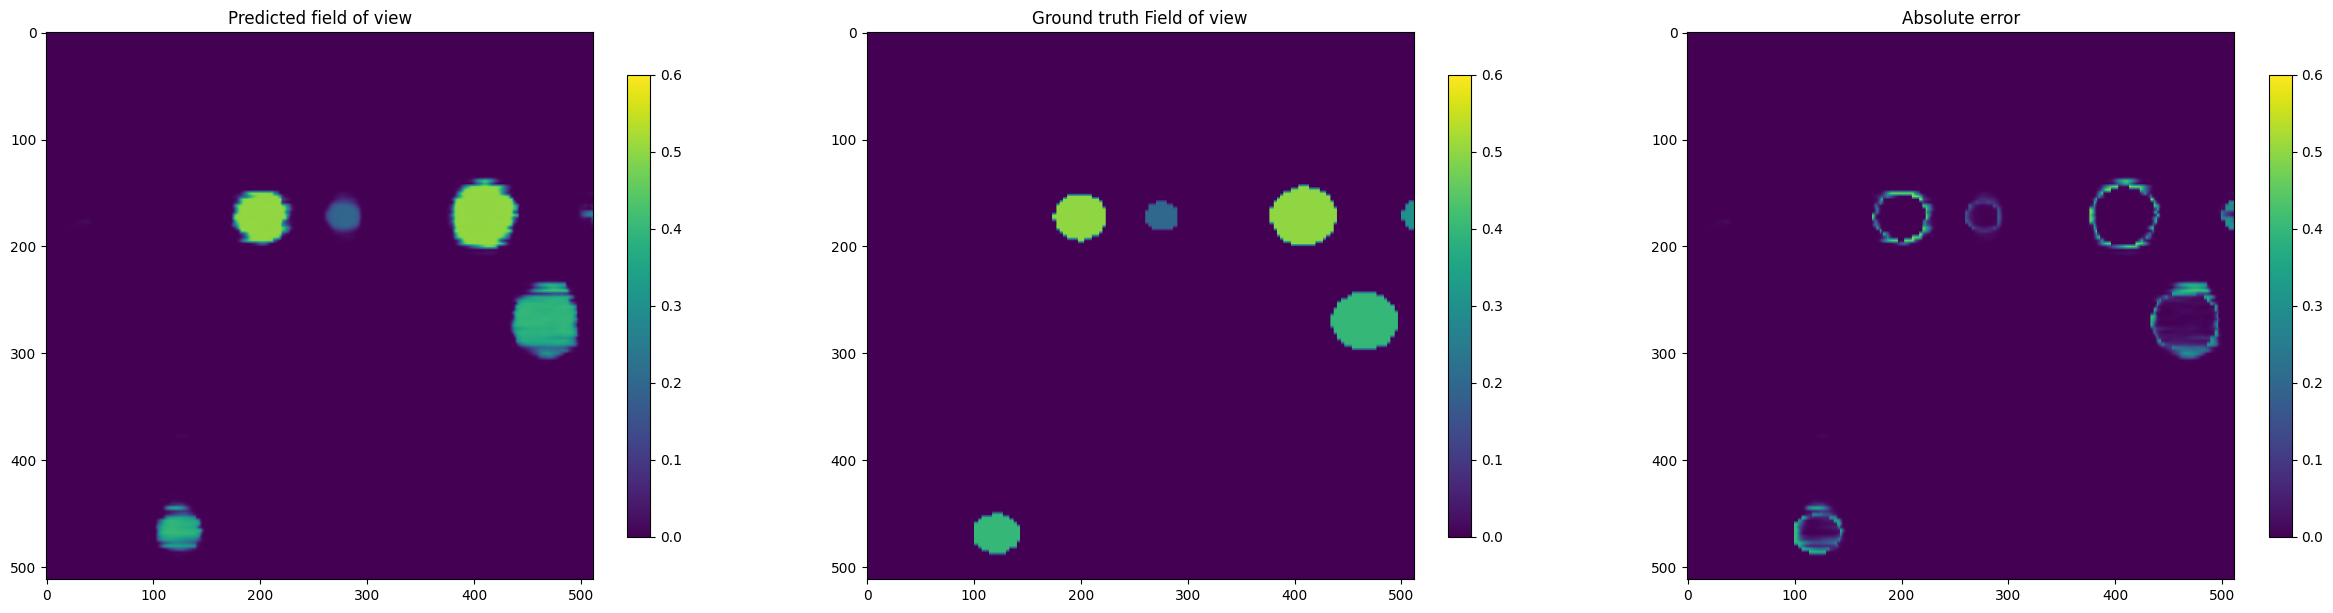

In [27]:
n=5
plt.figure(figsize=(30,12))
plt.subplot(1,3,1)
plt.imshow(resize_tensor(pred_all[174*n:174*(n+1),:],512,512),vmin=0,vmax=0.6)
plt.title(f'Predicted field of view')
plt.colorbar(shrink=0.5)


plt.subplot(1,3,2)
plt.imshow(resize_tensor(mask_all[174*n:174*(n+1),:],512,512),vmin=0,vmax=0.6)
plt.title(f'Ground truth Field of view')
plt.colorbar(shrink=0.5)

plt.subplot(1,3,3)
plt.imshow(resize_tensor(torch.abs(mask_all[174*n:174*(n+1),:]-pred_all[174*n:174*(n+1),:]),512,512),vmin=0,vmax=0.6)
plt.title(f'Absolute error')
plt.colorbar(shrink=0.5)
